# BoolDog features tutorial

Advanced demonstration of BoolDog functionalities.

In [1]:
# Pretty results!
from IPython.display import display, HTML, Image

# Utilities
from pathlib import Path

In [2]:
# Other tools
import py4cytoscape as p4c

In [3]:
# BoolDog classes and functions
from booldog import BoolDogModel
from booldog.io.biomodels import fetch_model_info, fetch_model

INFO 2026-03-01 11:35:36,257 booldog:<module> BoolDog version: 0.1.0
DEBUG 2026-03-01 11:35:36,258 booldog:<module> Test


## Util functions

In [4]:
def print_html(s):
    display(HTML(
    "<div style='width: 800px;'>" + \
     s +\
     "</div>"
    ))

In [5]:
files_path = Path("files")

## Fetch a model from BioModels

In [6]:
biomodel_id="BIOMD0000000562"
# model_info = fetch_model_info(model_id=biomodel_id)
# print_html(model_info["description"])

In [7]:
# model_info["modellingApproach"]

In [8]:
model_file = files_path / f"{biomodel_id}.xml"
print(model_file)
if not model_file.exists():
    fetch_model(biomodel_id, local_file=model_file)

files/BIOMD0000000562.xml


## Import SBML-qual model

In [9]:
bn = BoolDogModel.from_sbmlqual(model_file)

DEBUG 2026-03-01 11:35:36,296 booldog.io:_from_reader Creating BoolDogModel using reader read_sbmlqual
DEBUG 2026-03-01 11:35:36,305 booldog.io.sbml:parse_function ResultLevel 1
DEBUG 2026-03-01 11:35:36,306 booldog.io.sbml:parse_function nik >= theta_t1_nik <==> nik
DEBUG 2026-03-01 11:35:36,307 booldog.io.sbml:parse_function Activation: ['nik']
DEBUG 2026-03-01 11:35:36,308 booldog.io.sbml:parse_function Inhibition: []
DEBUG 2026-03-01 11:35:36,308 booldog.io.sbml:_get_all_rules Final rule: ikk : ( nik )
DEBUG 2026-03-01 11:35:36,309 booldog.io.sbml:parse_function ResultLevel 1
DEBUG 2026-03-01 11:35:36,310 booldog.io.sbml:parse_function mkk4 >= theta_t2_mkk4 <==> mkk4
DEBUG 2026-03-01 11:35:36,310 booldog.io.sbml:parse_function Activation: ['mkk4']
DEBUG 2026-03-01 11:35:36,312 booldog.io.sbml:parse_function Inhibition: []
DEBUG 2026-03-01 11:35:36,313 booldog.io.sbml:_get_all_rules Final rule: p38 : ( mkk4 )
DEBUG 2026-03-01 11:35:36,314 booldog.io.sbml:parse_function ResultLevel 1

## Load into Cytoscape

Make sure Cytoscape is running.

In [10]:
_ = p4c.cytoscape_ping()

You are connected to Cytoscape!


In [11]:
bn.to_cytoscape(as_logic_circuit=False)

Applying default style...
Applying preferred layout


6696

In [12]:
suid_main = bn.to_cytoscape(as_logic_circuit=True)

DEBUG 2026-03-01 11:35:37,285 booldog.io.circuit:booldog2circuit Processing rule for erk: ( mek )
DEBUG 2026-03-01 11:35:37,286 booldog.io.circuit:resolve_rule Replace mek with mek
DEBUG 2026-03-01 11:35:37,287 booldog.io.circuit:booldog2circuit Processing rule for ikk: ( nik )
DEBUG 2026-03-01 11:35:37,288 booldog.io.circuit:resolve_rule Replace nik with nik
DEBUG 2026-03-01 11:35:37,289 booldog.io.circuit:booldog2circuit Processing rule for gsk3: ( !akt )
DEBUG 2026-03-01 11:35:37,289 booldog.io.circuit:resolve_rule Replace !akt with not_0
DEBUG 2026-03-01 11:35:37,290 booldog.io.circuit:booldog2circuit Processing rule for nfkb: ( !ikb )
DEBUG 2026-03-01 11:35:37,291 booldog.io.circuit:resolve_rule Replace !ikb with not_1
DEBUG 2026-03-01 11:35:37,292 booldog.io.circuit:booldog2circuit Processing rule for ask1: ( traf2 )
DEBUG 2026-03-01 11:35:37,293 booldog.io.circuit:resolve_rule Replace traf2 with traf2
DEBUG 2026-03-01 11:35:37,294 booldog.io.circuit:booldog2circuit Processing ru

Applying default style...
Applying preferred layout


In [13]:
# save the Cytoscape session
p4c.save_session((files_path / "tutorial-features.cys").as_posix())

This file has been overwritten.


{}

## Boolean dynamics

### Case (i)

In [14]:
inactive_init_state = bn.inactivate_state(); inactive_init_state

BooleanStateSpace(network=<class 'booldog.network.BoolDogModel'> with 28 nodes, state_space=[{'akt': 0, 'ap1': 0, 'ask1': 0, 'cjun': 0, 'egf': 0, 'egfr': 0, 'erk': 0, 'ex': 0, 'gsk3': 0, 'ikb': 0, 'ikk': 0, 'jnk': 0, 'map3k1': 0, 'map3k7': 0, 'mek': 0, 'mkk4': 0, 'mkk7': 0, 'nfkb': 0, 'nik': 0, 'p38': 0, 'ph': 0, 'pi3k': 0, 'raf1': 0, 'ras': 0, 'sos': 0, 'tnfa': 0, 'tnfr': 0, 'traf2': 0}])

WARNING The state transition graph will consist of up to 2**28=268435456 states, depending on the initial states.


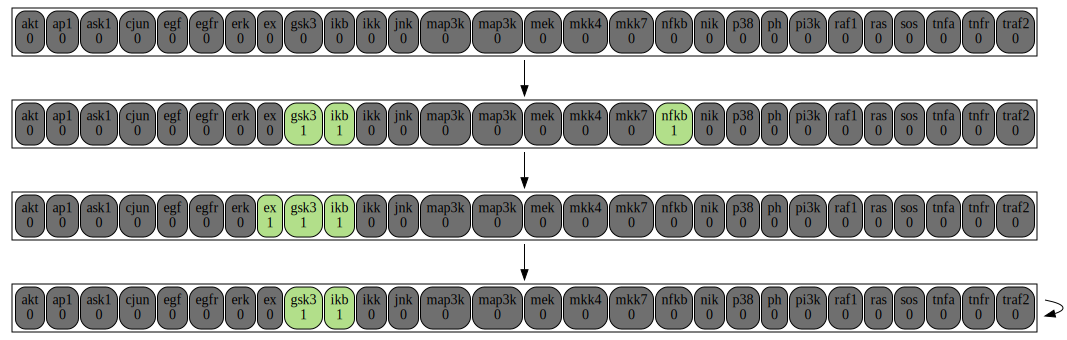

In [15]:
bsim_inactive = bn.boolean_simulation(initial_states=inactive_init_state)
bsim_inactive.plot_stg()

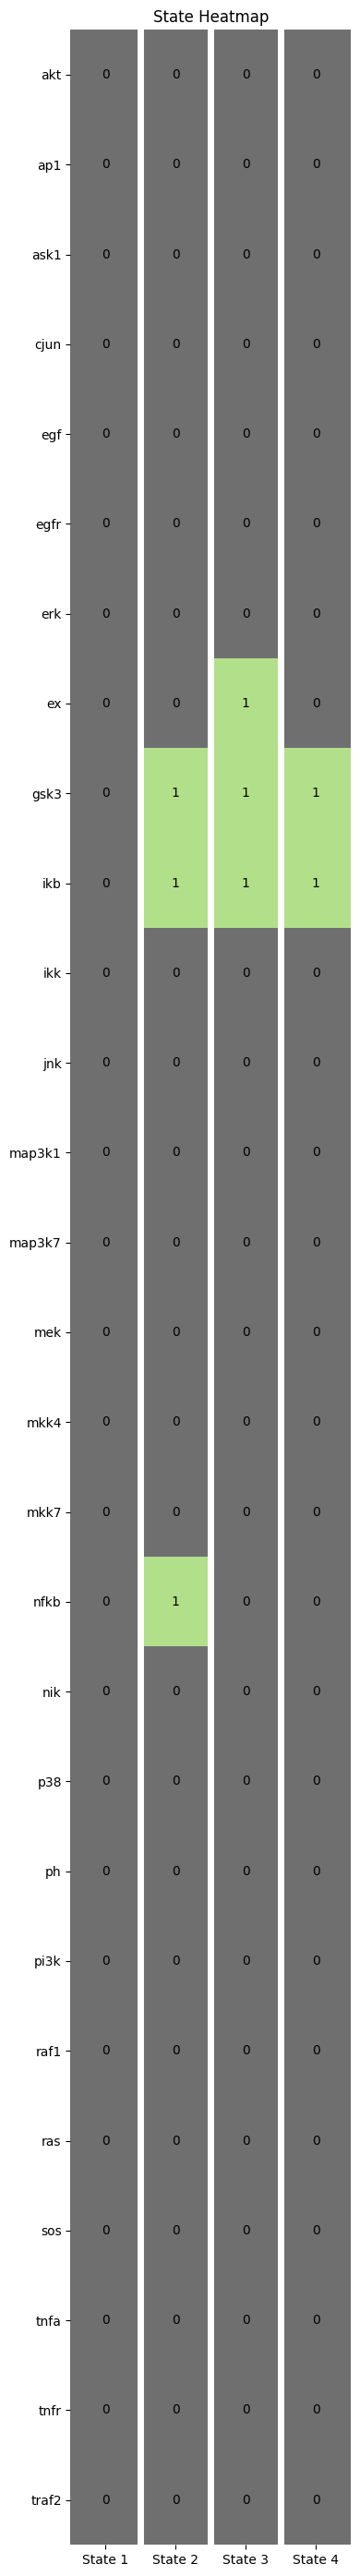

In [16]:
bsim_inactive.plot_state_space()

Compare the above plots to Figure 4A.

### Case (ii)

In [17]:
triggered_init_state = bn.inactivate_state(); 
triggered_init_state.set_node_state("egf", 1)
triggered_init_state.set_node_state("tnfa", 1)
triggered_init_state

BooleanStateSpace(network=<class 'booldog.network.BoolDogModel'> with 28 nodes, state_space=[{'akt': 0, 'ap1': 0, 'ask1': 0, 'cjun': 0, 'egf': 1, 'egfr': 0, 'erk': 0, 'ex': 0, 'gsk3': 0, 'ikb': 0, 'ikk': 0, 'jnk': 0, 'map3k1': 0, 'map3k7': 0, 'mek': 0, 'mkk4': 0, 'mkk7': 0, 'nfkb': 0, 'nik': 0, 'p38': 0, 'ph': 0, 'pi3k': 0, 'raf1': 0, 'ras': 0, 'sos': 0, 'tnfa': 1, 'tnfr': 0, 'traf2': 0}])

WARNING The state transition graph will consist of up to 2**28=268435456 states, depending on the initial states.


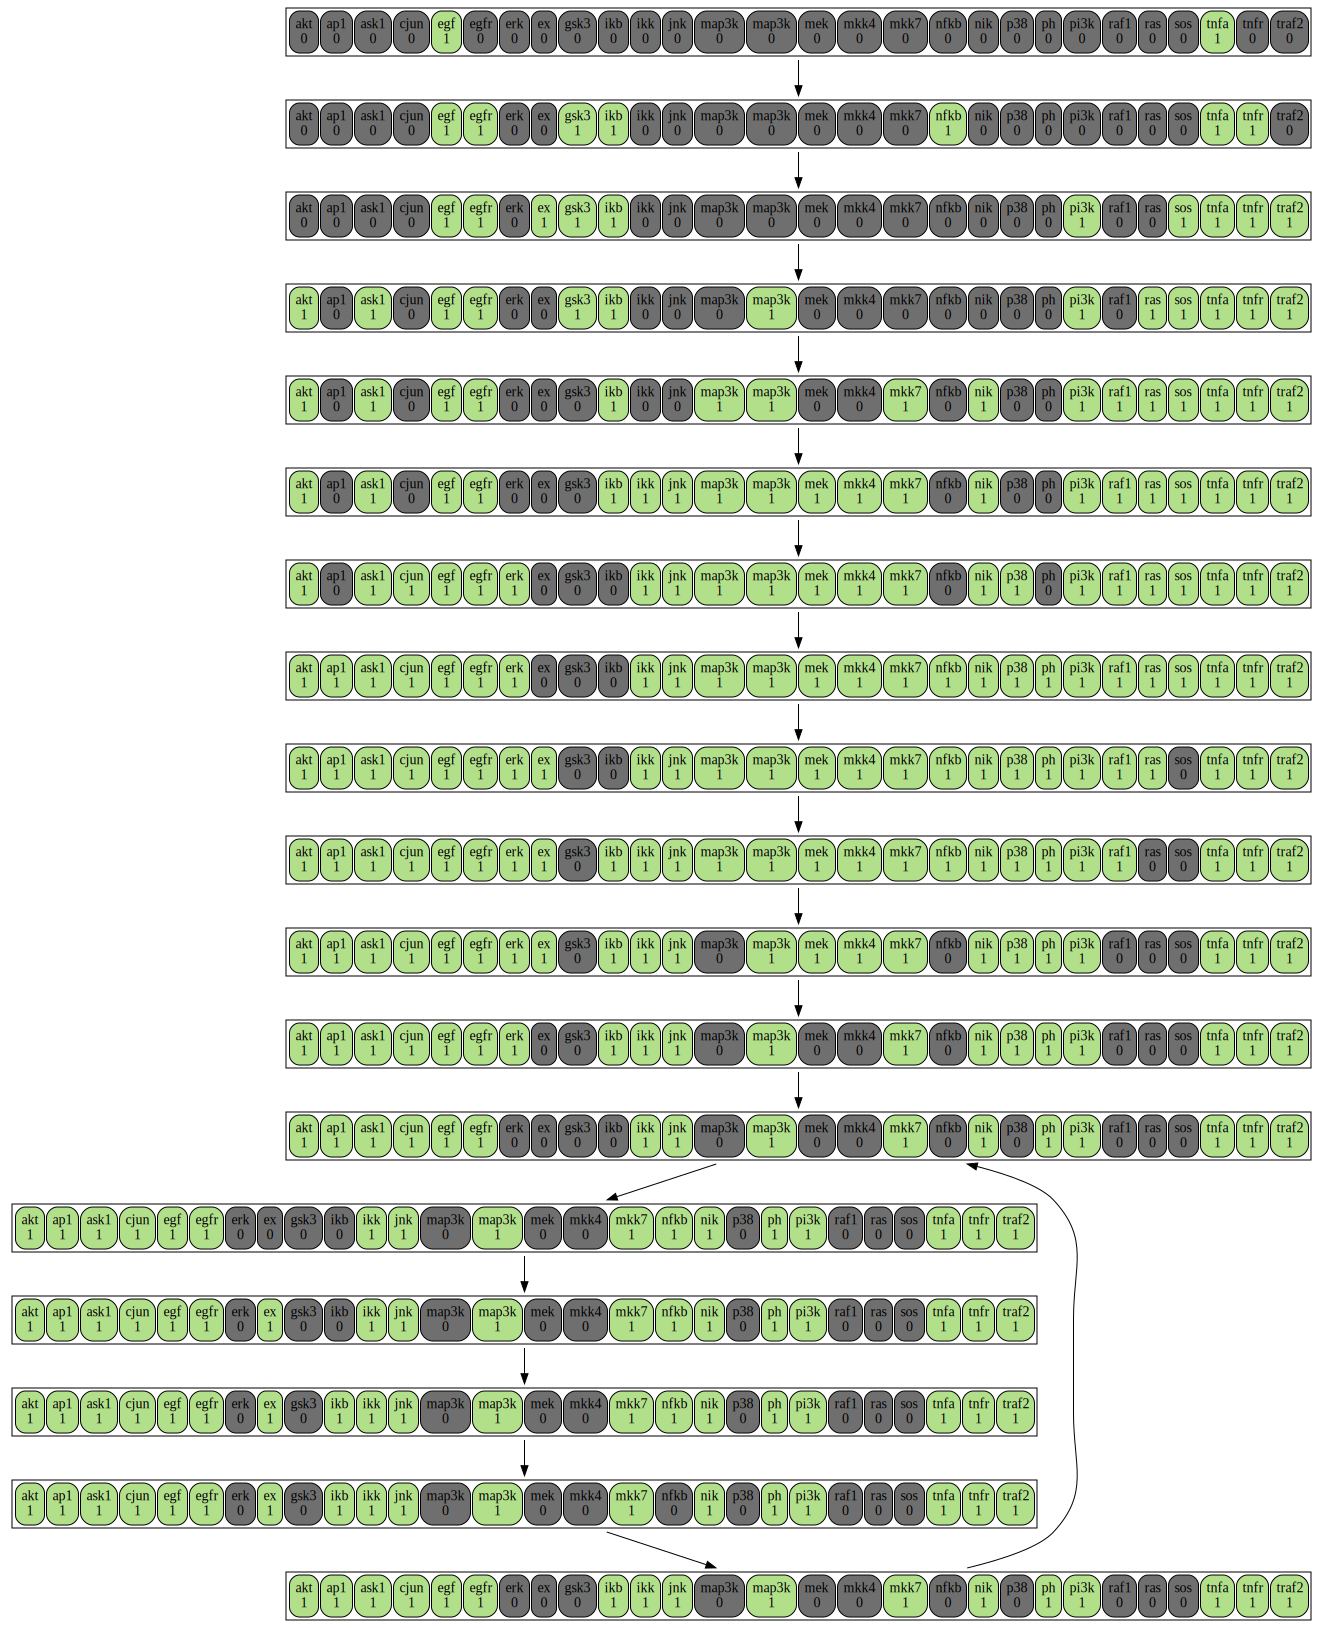

In [18]:
bsim_triggered = bn.boolean_simulation(initial_states=triggered_init_state)
bsim_triggered.plot_stg()

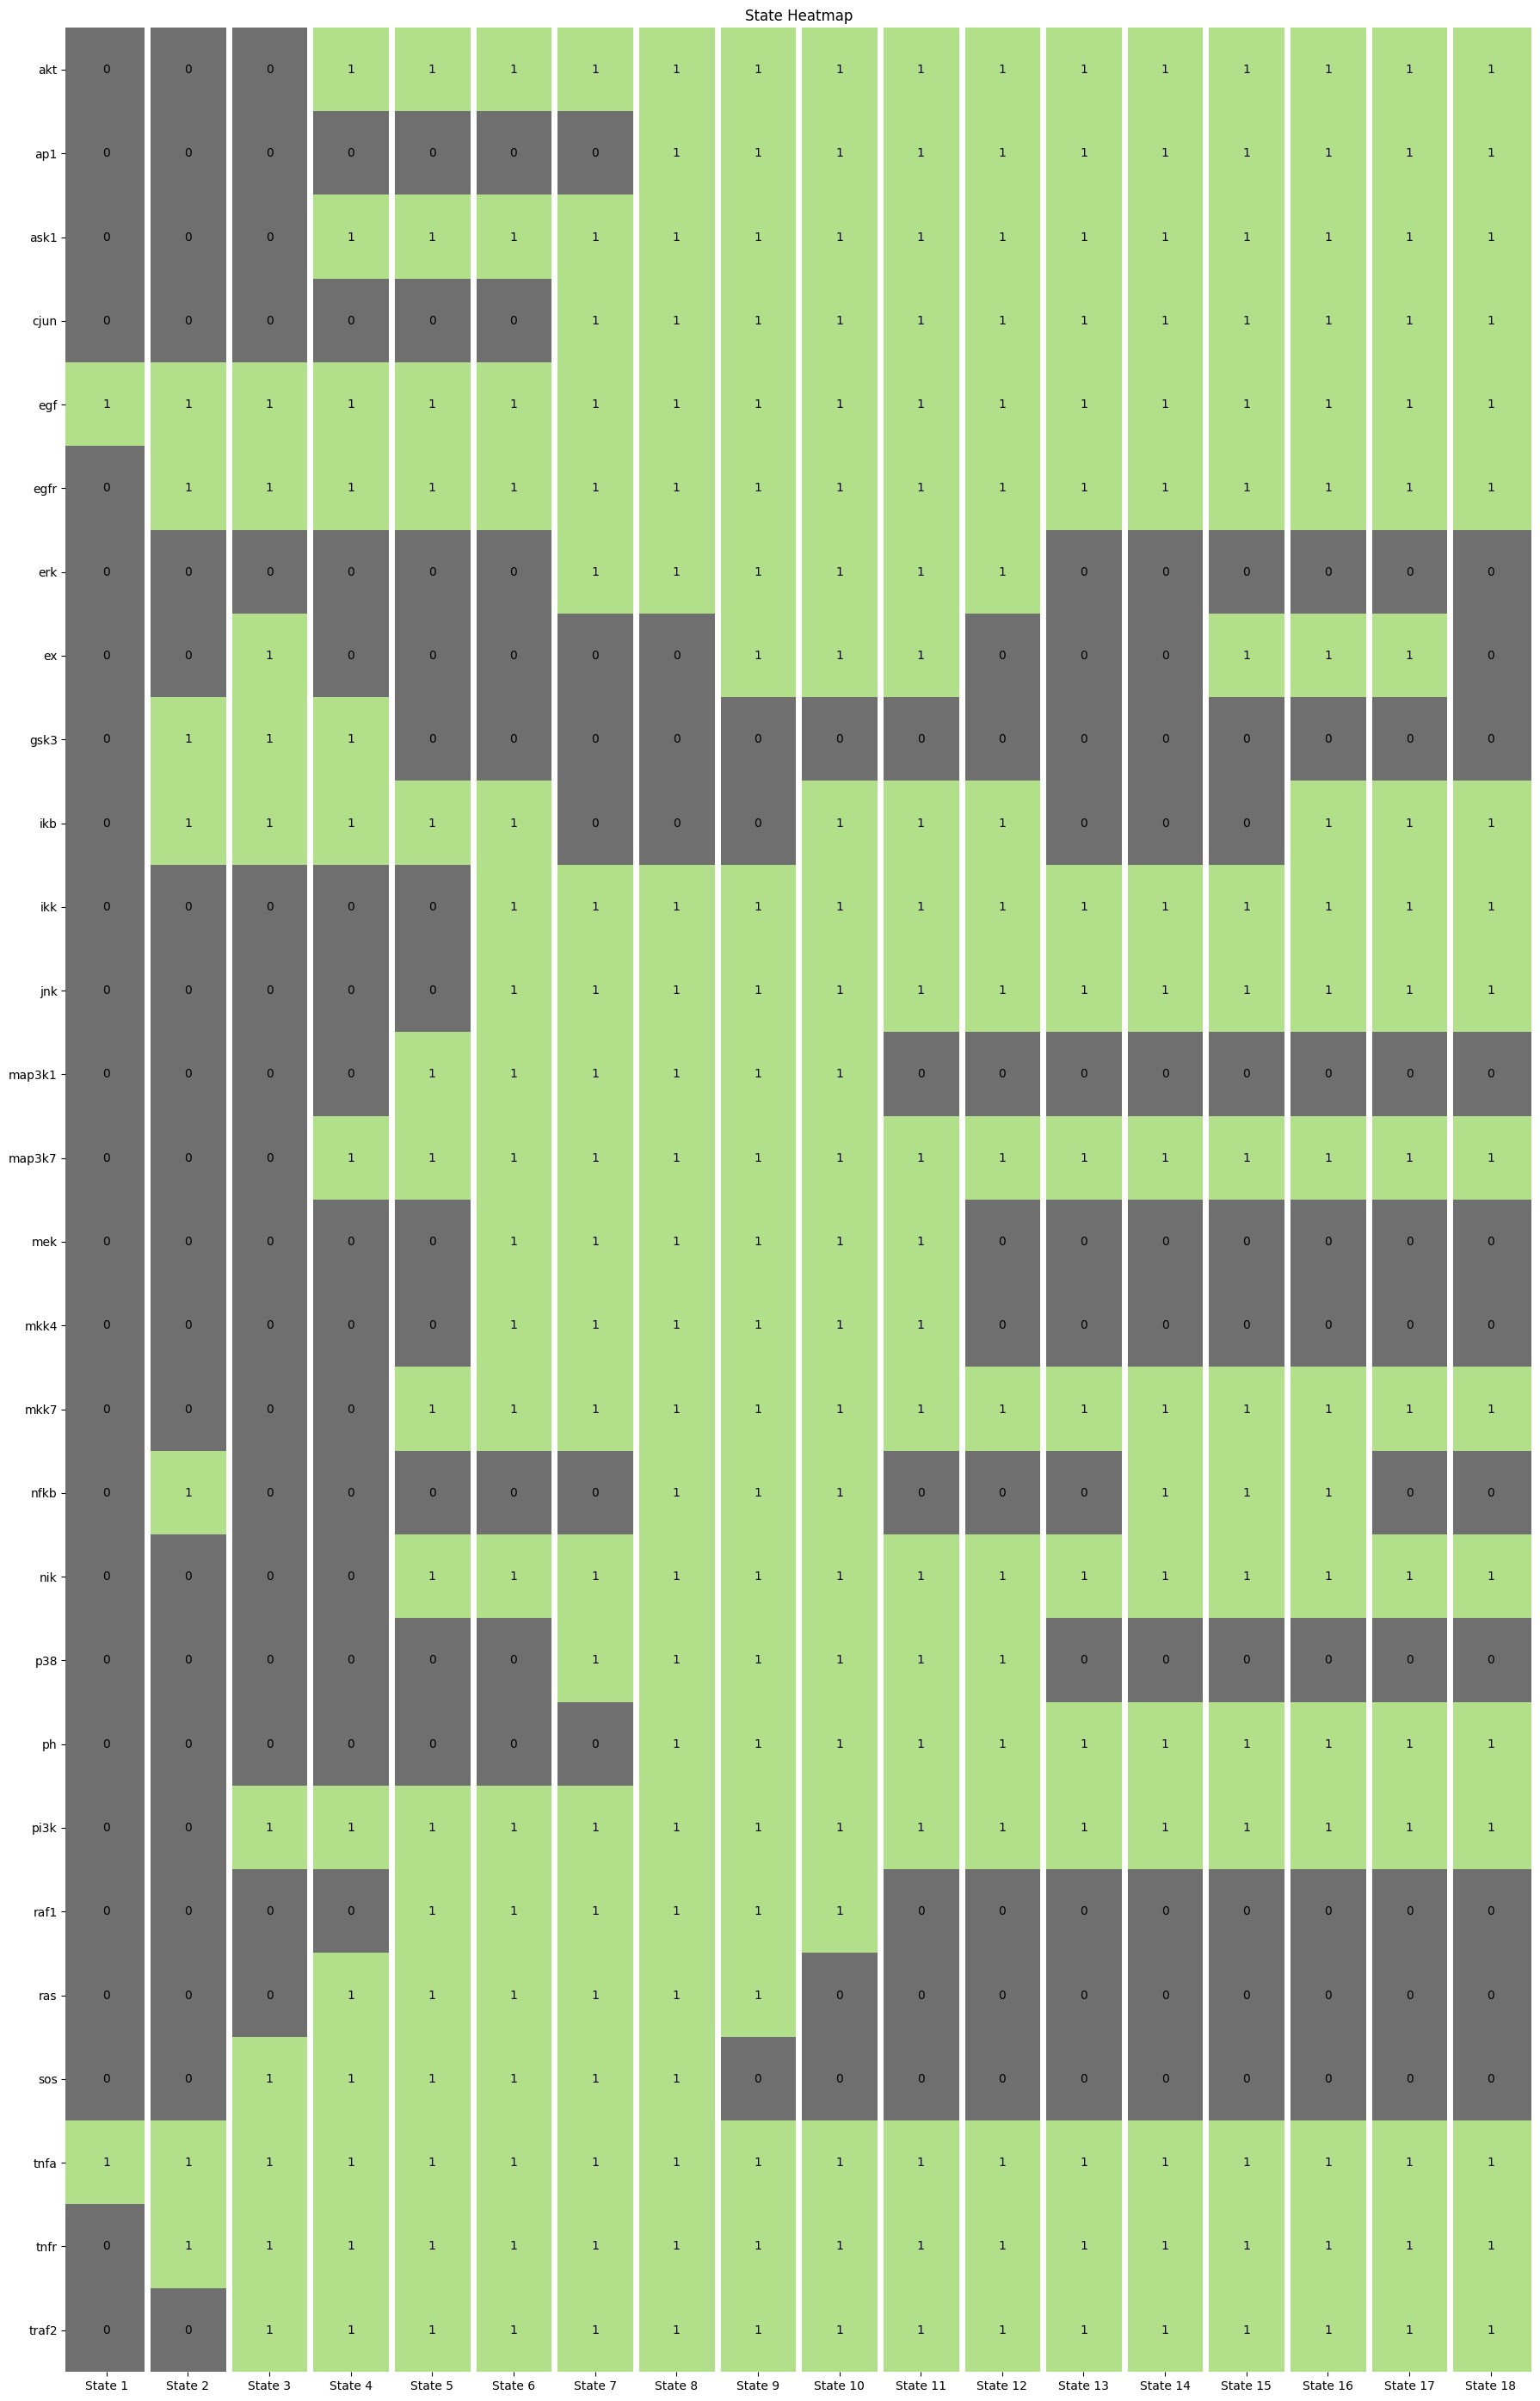

In [19]:
bsim_triggered.plot_state_space()

Compare the above plots to Figure 4B.

## Create animation from Boolean simulation

The animation is generated using Cytoscape, thus allowing a manual layout of the network as basis to the animation. 

In [20]:
# main_suid = 10673

gif = files_path / "triggered_ii.gif"

In [21]:
# bsim_triggered.make_animation(base_suid=main_suid, gif=gif)

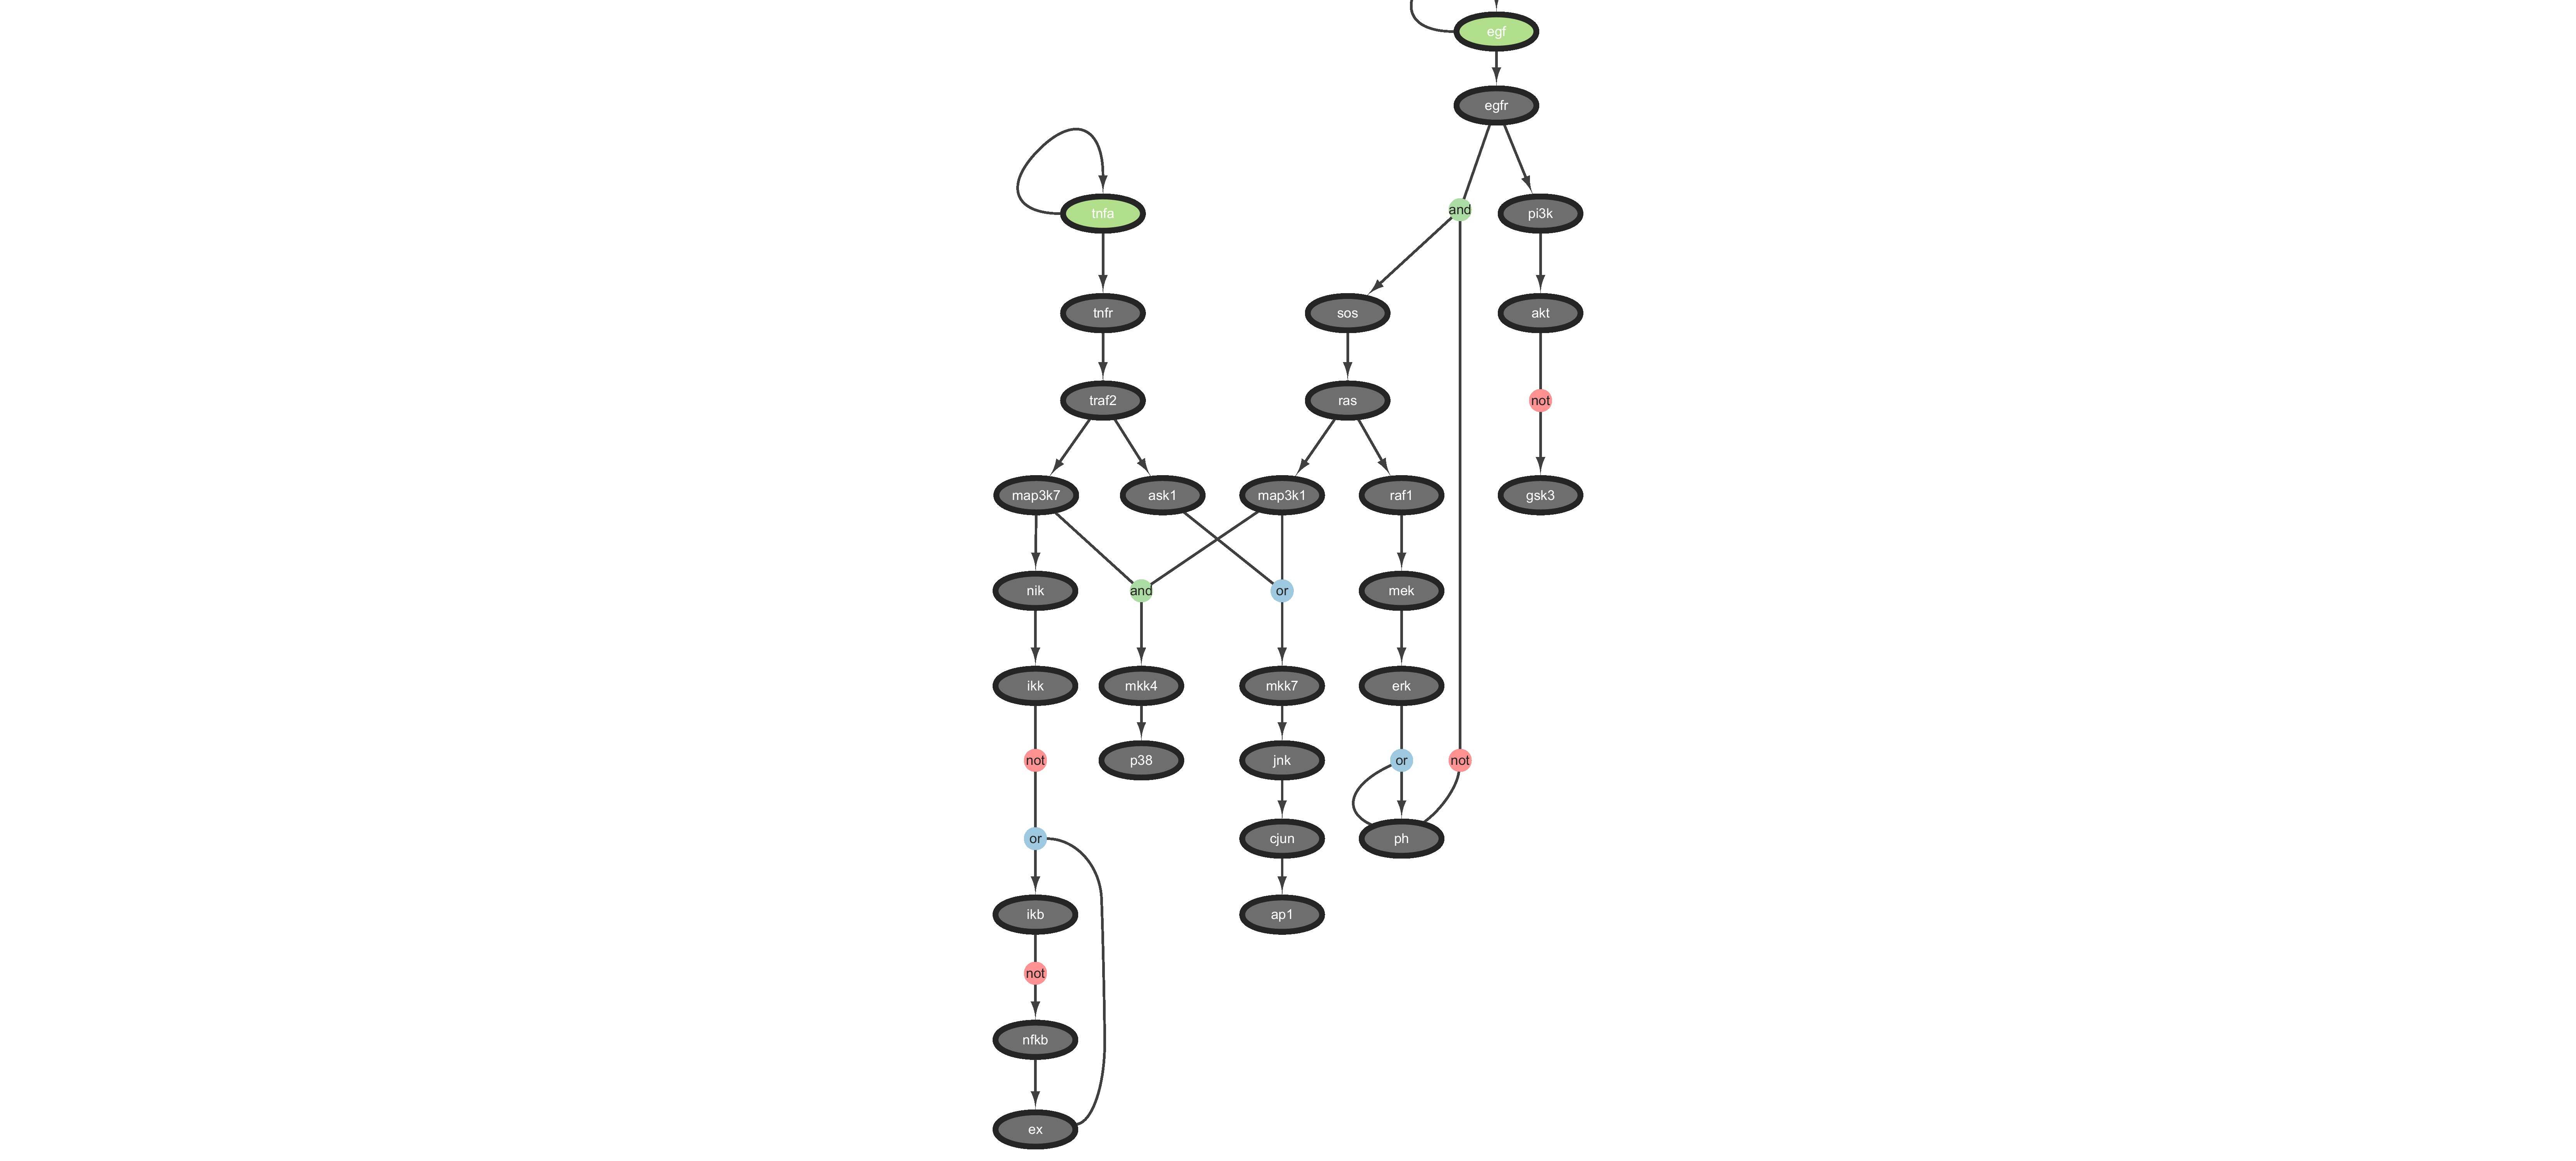

In [22]:
Image(gif)

## Modify the Boolean network

Possible modifications include:
- update/change a node rule
- remove a node
- add a node


A node cannot be removed if other nodes depend on it (i.e. it occurs in
their update logic). To remove such a node, either also remove all of
its dependants, or first update the logic rule of its dependants to
remove dependency.


In [23]:
bn.nodes['ph'].rule

'( ph | erk )'

In [24]:
bn.update_node('ph', 'erk')
bn.remove_nodes(['ex', 'ikb', 'nfkb'])
bn.add_node("new", "ph | mkk4")

In [25]:
print('ph -->', bn.nodes['ph'].rule)
print('new -->', bn.nodes['new'].rule)

ph --> erk
new --> ph | mkk4


In [26]:
# Lists all modifications to the model
bn.modifications

[Modification(type=update, node_id=ph, rule=erk),
 Modification(type=remove_node, node_id=['ex', 'ikb', 'nfkb'], rule=None),
 Modification(type=add_node, node_id=new, rule=ph | mkk4)]

In [27]:
bn.to_cytoscape(title="modified")

Applying default style...
Applying preferred layout


7601

## Export the Boolean network

In [28]:
# show the BNET format
print(bn.to_bnet())

targets, factors
erk, ( mek )
ikk, ( nik )
gsk3, ( !akt )
ask1, ( traf2 )
ras, ( sos )
egf, egf
egfr, ( egf )
traf2, ( tnfr )
map3k1, ( ras )
tnfr, ( tnfa )
ap1, ( cjun )
mek, ( raf1 )
mkk4, ( map3k7 & map3k1 )
tnfa, tnfa
raf1, ( ras )
map3k7, ( traf2 )
mkk7, ( ask1 | map3k1 )
cjun, ( jnk )
sos, ( egfr & !ph )
jnk, ( mkk7 )
pi3k, ( egfr )
p38, ( mkk4 )
akt, ( pi3k )
ph, erk
nik, ( map3k7 )
new, ph | mkk4



In [30]:
# or save to SBML-qual
bn.to_sbmlqual(files_path / f"{bn.modelinfo.identifier}-booldog-sbmlqual.xml")

INFO 2026-03-01 11:35:42,251 booldog.io.sbml:write Wrote Network as a Boolean model in SBML-qual to files/MODEL1411240000-booldog-bmlqual.xml


## NetworkX network

In [33]:
g = bn.to_networkx(as_logic_circuit=False)

In [34]:
g.in_degree()

InDegreeView({'akt': 1, 'ap1': 1, 'ask1': 1, 'cjun': 1, 'egf': 1, 'egfr': 1, 'erk': 1, 'gsk3': 1, 'ikk': 1, 'jnk': 1, 'map3k1': 1, 'map3k7': 1, 'mek': 1, 'mkk4': 2, 'mkk7': 2, 'nik': 1, 'p38': 1, 'ph': 1, 'pi3k': 1, 'raf1': 1, 'ras': 1, 'sos': 2, 'tnfa': 1, 'tnfr': 1, 'traf2': 1, 'new': 2})

In [36]:
import networkx as nx

In [39]:
nx.connectivity.average_node_connectivity(g)

0.2753846153846154

In [41]:
nx.centrality.degree_centrality(g)

{'akt': 0.08,
 'ap1': 0.04,
 'ask1': 0.08,
 'cjun': 0.08,
 'egf': 0.12,
 'egfr': 0.12,
 'erk': 0.08,
 'gsk3': 0.04,
 'ikk': 0.04,
 'jnk': 0.08,
 'map3k1': 0.12,
 'map3k7': 0.12,
 'mek': 0.08,
 'mkk4': 0.16,
 'mkk7': 0.12,
 'nik': 0.08,
 'p38': 0.04,
 'ph': 0.12,
 'pi3k': 0.08,
 'raf1': 0.08,
 'ras': 0.12,
 'sos': 0.12,
 'tnfa': 0.12,
 'tnfr': 0.08,
 'traf2': 0.12,
 'new': 0.08}

## Semi-quantative simulations

In [44]:
simulation = bn.continuous_simulation(
    t_max=5, 
    transform="normalisedhillcube"
)

INFO 2026-03-01 13:17:25,980 booldog.semi_quantitative:continuous_simulation Status: Generating ODE system ... 
INFO 2026-03-01 13:17:25,981 booldog.ode_factory:__init__ Creating ODE system for normalisedhillcube.


TypeError: unsupported operand type(s) for -: 'list' and 'set'

(<Figure size 2000x1000 with 1 Axes>, array([[<Axes: >]], dtype=object))

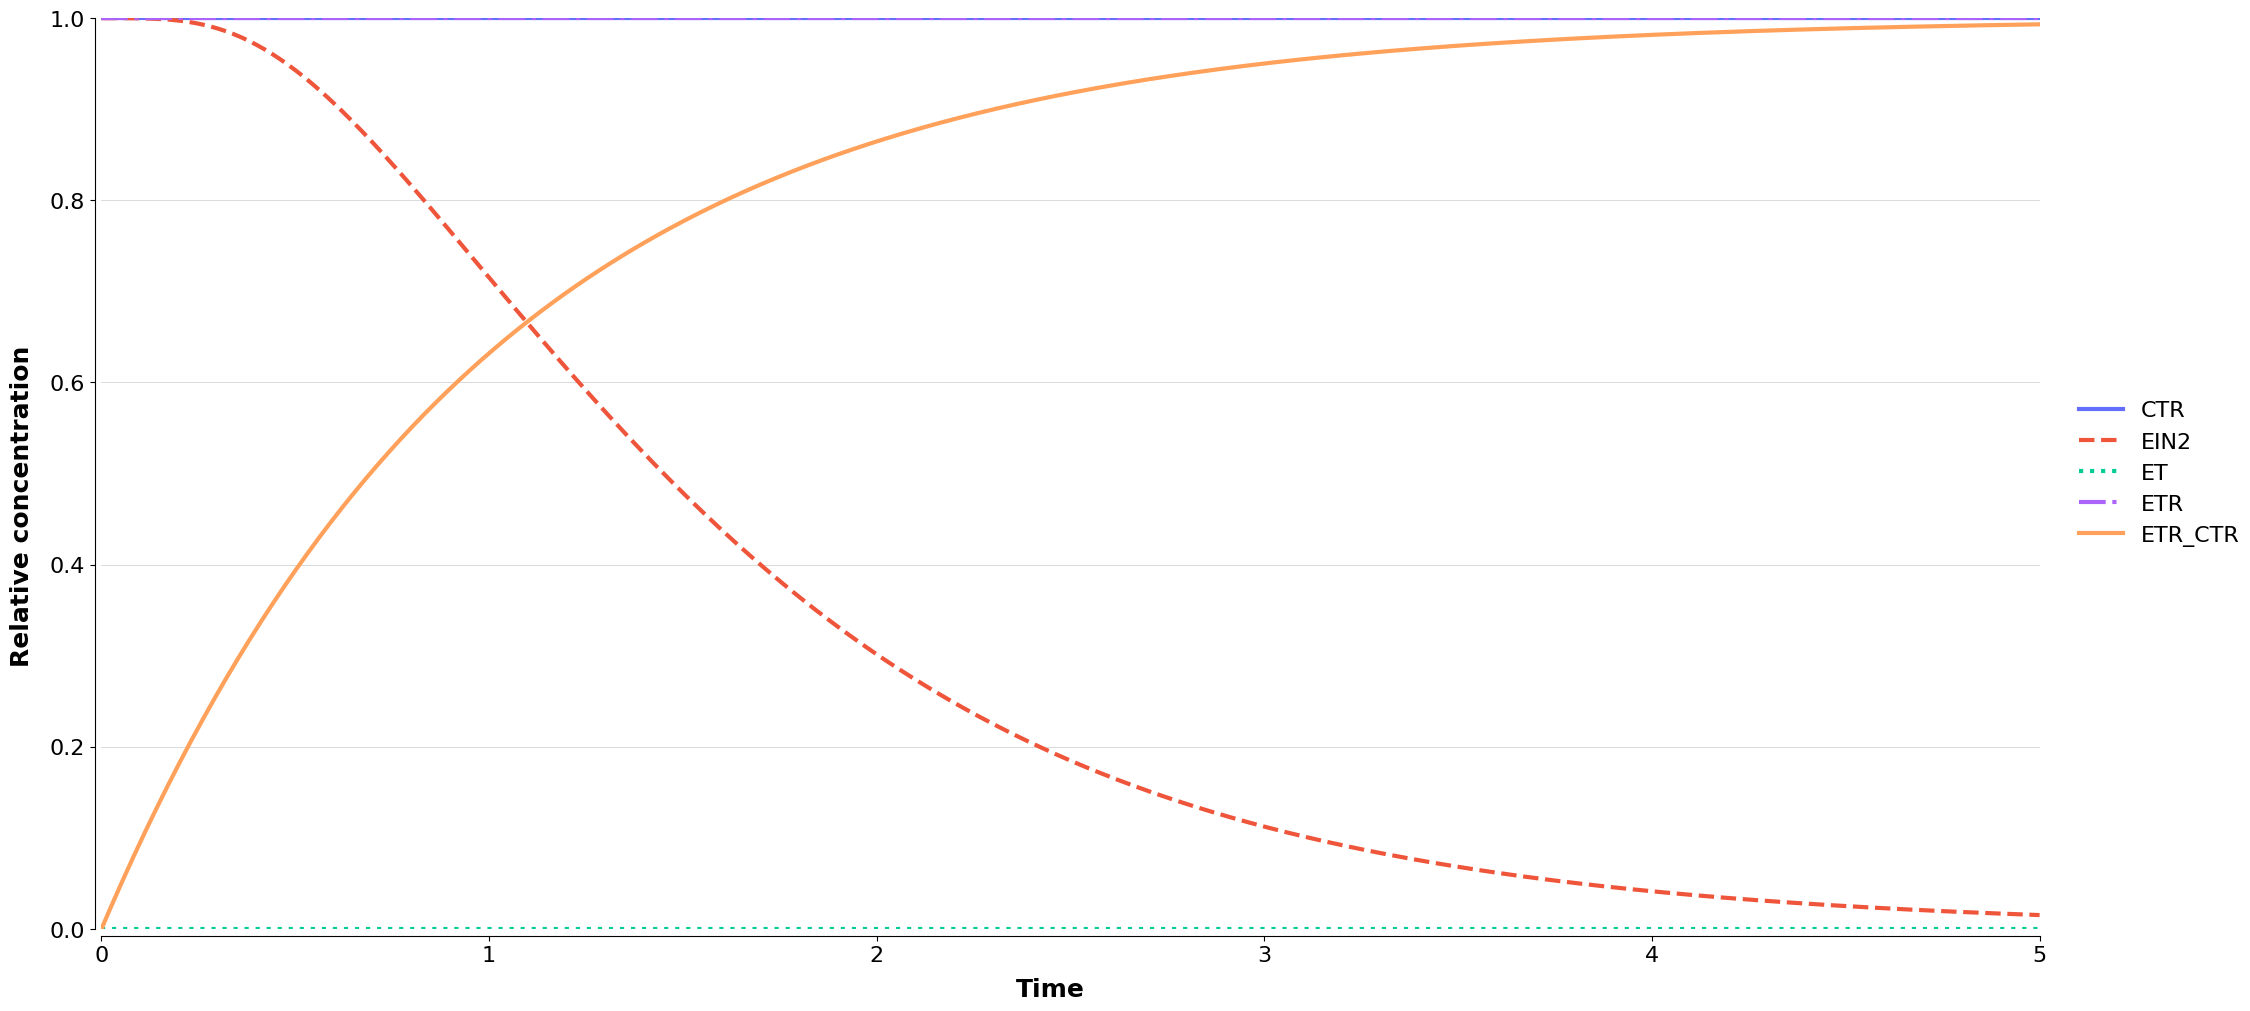

In [10]:
simulation.plot()

In [11]:
simulation.y

array([[1.        , 1.        , 0.        , 1.        , 0.        ],
       [1.        , 1.        , 0.        , 1.        , 0.00172882],
       [1.        , 0.99999996, 0.        , 1.        , 0.01166179],
       ...,
       [1.        , 0.01549362, 0.        , 1.        , 0.99313782],
       [1.        , 0.01533946, 0.        , 1.        , 0.9932061 ],
       [1.        , 0.01521313, 0.        , 1.        , 0.99326205]])

In [10]:
g.nodes

{'CTR': BoolDogNode(name=CTR protein),
 'EIN2': BoolDogNode(name=EIN2 protein),
 'ET': BoolDogNode(name=ET metabolite),
 'ETR': BoolDogNode(name=ETR protein),
 'ETR_CTR': BoolDogNode(name=ETR|CTR complex)}

In [4]:
bnet = '''
CNGC2, Heat
Ca2, CNGC2
PIF34, PIF34 & !DELLA
PIF7, ( Heat )
HSF, (PIF34 & PIF7) | Heat
HSP, HSF
CDPK, ( Ca2 )
CMLCa2, ( Ca2 )
RBOH, ( CDPK | Ca2 | ERF74 )
CAT, CMLCa2 & !SA
SA, ICS
ICS, CBP60G | SARD1
CBP60G, CMLCa2
SARD1, CMLCa2
ROS, RBOH & !CAT & !ROS-sc & !APX
ROS-sc, ROS
'''

In [5]:
g = booldog.RegulatoryNetwork(bnet,
                              data_format="bnet")
for n in g.nodes:
	print(f"   '{n}':0,")

Imported Boolean graph with 20 nodes
   'APX':0,
   'CAT':0,
   'CBP60G':0,
   'CDPK':0,
   'CMLCa2':0,
   'CNGC2':0,
   'Ca2':0,
   'DELLA':0,
   'ERF74':0,
   'HSF':0,
   'HSP':0,
   'Heat':0,
   'ICS':0,
   'PIF34':0,
   'PIF7':0,
   'RBOH':0,
   'ROS':0,
   'ROS-sc':0,
   'SA':0,
   'SARD1':0,


In [6]:
initial_state = {
    'CAT':0,
    'CBP60G':0,
    'CDPK':0,
    'CMLCa2':0,
    'CNGC2':0,
    'Ca2':0,
    'DELLA':0,
    'HSF':0,
    'HSP':0,
    'Heat':0,
    'ICS':0,
    'PIF34':0,
    'PIF7':0,
    'RBOH':0,
    'ROS':0,
    'SA':0,
    'SARD1':0,
    'ROS-sc':0,
    'APX':0,
    'ERF74':0
}

In [61]:
# g.plot_state_transitions?

In [62]:
# g.plot_state_transitions("heat-stg-complete.pdf", new_style=False)

In [164]:
g.plot_state_transitions("heat-stg.png", initial_values=initial_state)

The state transition graph will consist of up to 2**20=1048576 states, depending on the InitialStates. 
This will take a while and we might run out of memory.
Saved figure to heat-stg.png. 


In [178]:
initial_state['Heat'] = 1
g.plot_state_transitions("heaton-stg.png", initial_values=initial_state)

The state transition graph will consist of up to 2**20=1048576 states, depending on the InitialStates. 
This will take a while and we might run out of memory.
Saved figure to heaton-stg.png. 


In [67]:
ss = g.steady_states()

In [68]:
len(ss)

12

In [140]:
import py4cytoscape as p4c

In [167]:
from collections import defaultdict

In [171]:
def export_network(network, filename, format="png"):

    # fit content ignores edges that may extend
    # past the node boundaries
    # Reported bug: CSD-979 - response from Dev team is NOT_FIX
    p4c.network_views.fit_content(network=network)
    p4c.network_selection.clear_selection(type='both', network=network)

    p4c.network_views.export_image(
        filename=filename,
        type=format,
        network=network,
        overwrite_file=True,
        resolution=600
        # all_graphics_details=True,
        # hide_labels=False
    )


In [ ]:
'''
        if new_style and (importlib.util.find_spec('pygraphviz') is not None):
            import networkx as nx

            rev_index = {}
            for node in self.nodes:
                rev_index[self.index[node]] = node


            stg.graph['node']['shape'] = 'plaintext'
            colors = {"1":"#80ff8a", "0":"#ff9580"}

            for n in stg:
                label = '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="1" ><TR>'
                for i, x in enumerate(n):
                    label += f'<TD BGCOLOR="{colors[x]}">{rev_index[i][:5]} <BR/> {x} </TD>'
                label += """</TR></TABLE>>"""
                stg.nodes[n]["label"]=label

            A = nx.drawing.nx_agraph.to_agraph(stg)
            A.layout('dot')
            A.draw(fig)
            print(f"Saved figure to {fig}. ")



In [179]:
stg = booldog.bool_graph.StateTransitionGraphs.primes2stg(g.primes,
                                                   "synchronous",
                                                   initial_state)

The state transition graph will consist of up to 2**20=1048576 states, depending on the InitialStates. 
This will take a while and we might run out of memory.


In [180]:
rev_index = {}
for node in g.nodes:
    rev_index[g.index[node]] = node
colors = {"1":"#238B45", "0":"#CCCCCC"}

In [181]:
colours_for_layer = defaultdict(dict)

In [182]:
for n in stg:
    for i, x in enumerate(n):
#         print(rev_index[i][:5], colors[x])
        colours_for_layer[n][rev_index[i]] = colors[x]
#     stg.nodes[n]["color"]=label

In [141]:
base_suid = p4c.clone_network(base_suid)

In [186]:
base_suid

7429

In [138]:
# base_suid = 7429

In [204]:
export_network(base_suid, f"base_.png", format="png")

In [194]:
state = '0'*g.n
select_result = p4c.select_all_nodes(network=base_suid)
suid = p4c.networks.create_subnetwork(
        nodes=select_result,
        subnetwork_name=state,
        network=base_suid
    )

for n in g.nodes:
    nodes_by_suid = p4c.select_nodes([n], by_col="name", network=suid)['nodes']
    p4c.style_bypasses.set_node_color_bypass(
        node_names=nodes_by_suid,
        new_colors=colors['0'],
        network=suid
    )
p4c.network_selection.clear_selection(type='both', network=suid)
export_network(suid, f"state_{state}.png", format="png")

In [189]:
nodes_by_suid


[7588]

In [190]:
n

'SARD1'

In [198]:
for state in colours_for_layer:
    select_result = p4c.select_all_nodes(network=base_suid)
    suid = p4c.networks.create_subnetwork(
            nodes=select_result,
            subnetwork_name=state,
            network=base_suid
        )

    for n in colours_for_layer[state]:
        nodes_by_suid = p4c.select_nodes([n], by_col="name", network=suid)['nodes']
        p4c.style_bypasses.set_node_color_bypass(
            node_names=nodes_by_suid,
            new_colors=colours_for_layer[state][n],
            network=suid
        )

    p4c.network_selection.clear_selection(type='both', network=suid)
    export_network(suid, f"state_{state}.png", format="png")


In [199]:
files = [f"state_{'0'*g.n}.png"] + [f"state_{state}.png" for state in colours_for_layer]
files

['state_00000000000000000000.png',
 'state_00000000000100000000.png',
 'state_00000100010100100000.png',
 'state_00000110011100100000.png',
 'state_00011110011100110000.png',
 'state_01111110011100111001.png',
 'state_01111110011110110101.png',
 'state_01111110011110110011.png',
 'state_00111110011110110011.png',
 'state_00111110011110111011.png',
 'state_00111110011110111111.png',
 'state_00111110011110110111.png']

In [200]:
files[-4:]

['state_00111110011110110011.png',
 'state_00111110011110111011.png',
 'state_00111110011110111111.png',
 'state_00111110011110110111.png']

In [201]:
files = files + files[-4:]*10

In [202]:
import contextlib
from PIL import Image


In [203]:

# filepaths
fp_out = "image.gif"

# use exit stack to automatically close opened images
with contextlib.ExitStack() as stack:

    # lazily load images
    imgs = (stack.enter_context(Image.open(f))
            for f in files)

    # extract  first image from iterator
    img = next(imgs)

    # https://pillow.readthedocs.io/en/stable/handbook/image-file-formats.html#gif
    img.save(fp=fp_out, format='GIF', append_images=imgs,
             save_all=True, duration=400, loop=0)


In [7]:
initial_state = {
   'CAT':0,
   'CBP60G':0,
   'CDPK':0,
   'CMLCa2':0,
   'CNGC2':0,
   'Ca2':0,
   'DELLA':0,
   'HSF':0,
   'HSP':0,
   'Heat':0,
   'ICS':0,
   'PIF34':0,
   'PIF7':0,
   'RBOH':0,
   'ROS':0,
   'SA':0,
   'SARD1':0,
    'ROS-sc':0,
    'APX':0
}

In [8]:
g.nodes

('APX',
 'CAT',
 'CBP60G',
 'CDPK',
 'CMLCa2',
 'CNGC2',
 'Ca2',
 'DELLA',
 'ERF74',
 'HSF',
 'HSP',
 'Heat',
 'ICS',
 'PIF34',
 'PIF7',
 'RBOH',
 'ROS',
 'ROS-sc',
 'SA',
 'SARD1')

```
tau : int, float, or dict, optional
    life-time of species

n : int, float, or dict, optional
    Hill coefficient

k : int, float, or dict, optional
    Hill dissociation constant

The Hill coefficient n determines the slope of the curve and is a measure of
the cooperativity of the interaction. The parameter k corresponds to the
threshold in the Boolean model, above which one defines the state of a species
as 'on'. Mathematically speaking, it is the value at which the activation is
half maximal.
```

Initialising ODE system ... done. 
Status: Start
Status: Event at   5:
      Heat -> 0.40 (duration 20)

Status: Event at  25:
      Heat -> 0.00 (duration  0)

Status: End


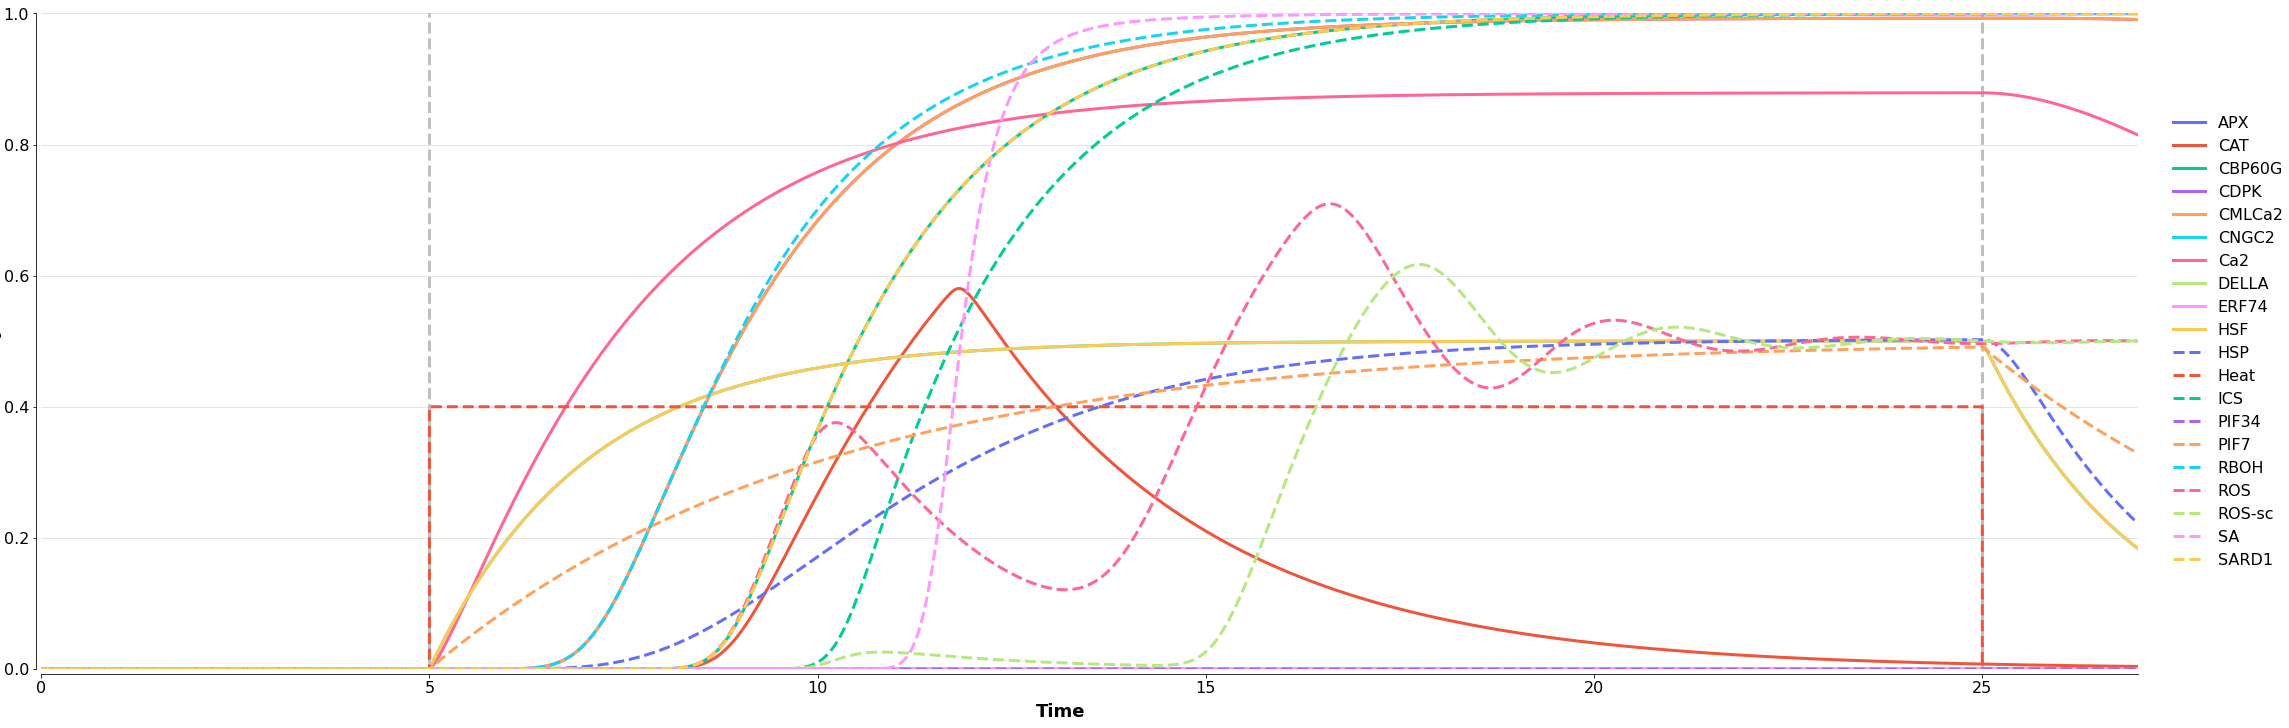

In [7]:
X = g.continuous_simulation(t_max=27, transform="normalisedhillcube",
                        initial_state=initial_state,
                        node_events=[
                            {'time':5,  'node':'Heat', 'value':0.4, 'duration':20},
                            {'time':25,  'node':'Heat', 'value':0},
                        ],
                        tau={
                            'default':2,
                            'CAT':3,
#                             'ROS':0.4,
#                             'Heat':-1
#                             'CNGC2':0.4,
                            'PIF7':5,
                            'SA':0.1
                        },
                        n={
                            'default':8,
                            'CNGC2':0.4
                        },
                        k={
                            'default':0.5,
                            'CAT':0.3,
                            'Heat':0.4
                        },
#                        export="./rna-sil-simulation-other.tsv"
)



Initialising ODE system ... done. 
Status: Start
Status: Event at   1:
      Heat -> 0.40 (duration 14)

Status: Event at  15:
      Heat -> 0.00 (duration  0)

Status: End


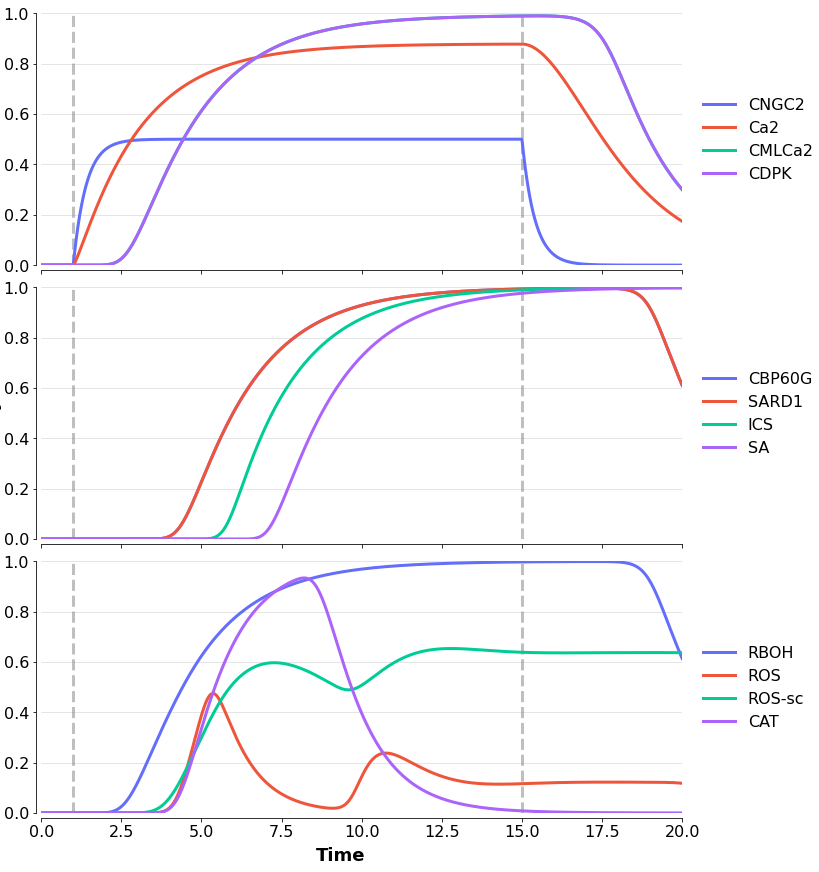

In [11]:
X = g.continuous_simulation(t_max=20, transform="normalisedhillcube",
                        initial_state=initial_state,
                        node_events=[
                            {'time':1,  'node':'Heat', 'value':0.4, 'duration':14},
                            {'time':15,  'node':'Heat', 'value':0},
                        ],
                        tau={
                            'default':2,
                            'CAT':1.2,
                            'ROS':1,#0.4,
                            'CNGC2':0.4,
                            'PIF7':5,
#                             'Ca2':0.1
                        },
                        n={
                            'default':8,
                            'CNGC2':0.4,
                            'ROS':0.4
                        },
                        k={
                            'default':0.5,
#                             'CAT':1,
                            'Heat':0.4,
#                             'ROS-sc':2,
                        },
#                        export="./rna-sil-simulation-other.tsv"
    plot_nodes = [
    # [
    # 'Heat',
    # 'PIF7',
    # 'HSF',
    # 'HSP'
    # ],


    [
    'CNGC2',
    'Ca2',
    'CMLCa2',
    'CDPK',
    ],
    ['CBP60G',
    'SARD1' ,
    'ICS',
    'SA',
    ]   ,

    [
    'RBOH',
    'ROS',
        'ROS-sc',
    'CAT',                            
#     'SA',
    #                             
    ]

    ],
    figsize=(10,12)
                            
                            
                            
)
# plt.savefig("ode-plot-1.svg", dpi=600, bbox_inches='tight')


IndexError: index 9 is out of bounds for axis 1 with size 5

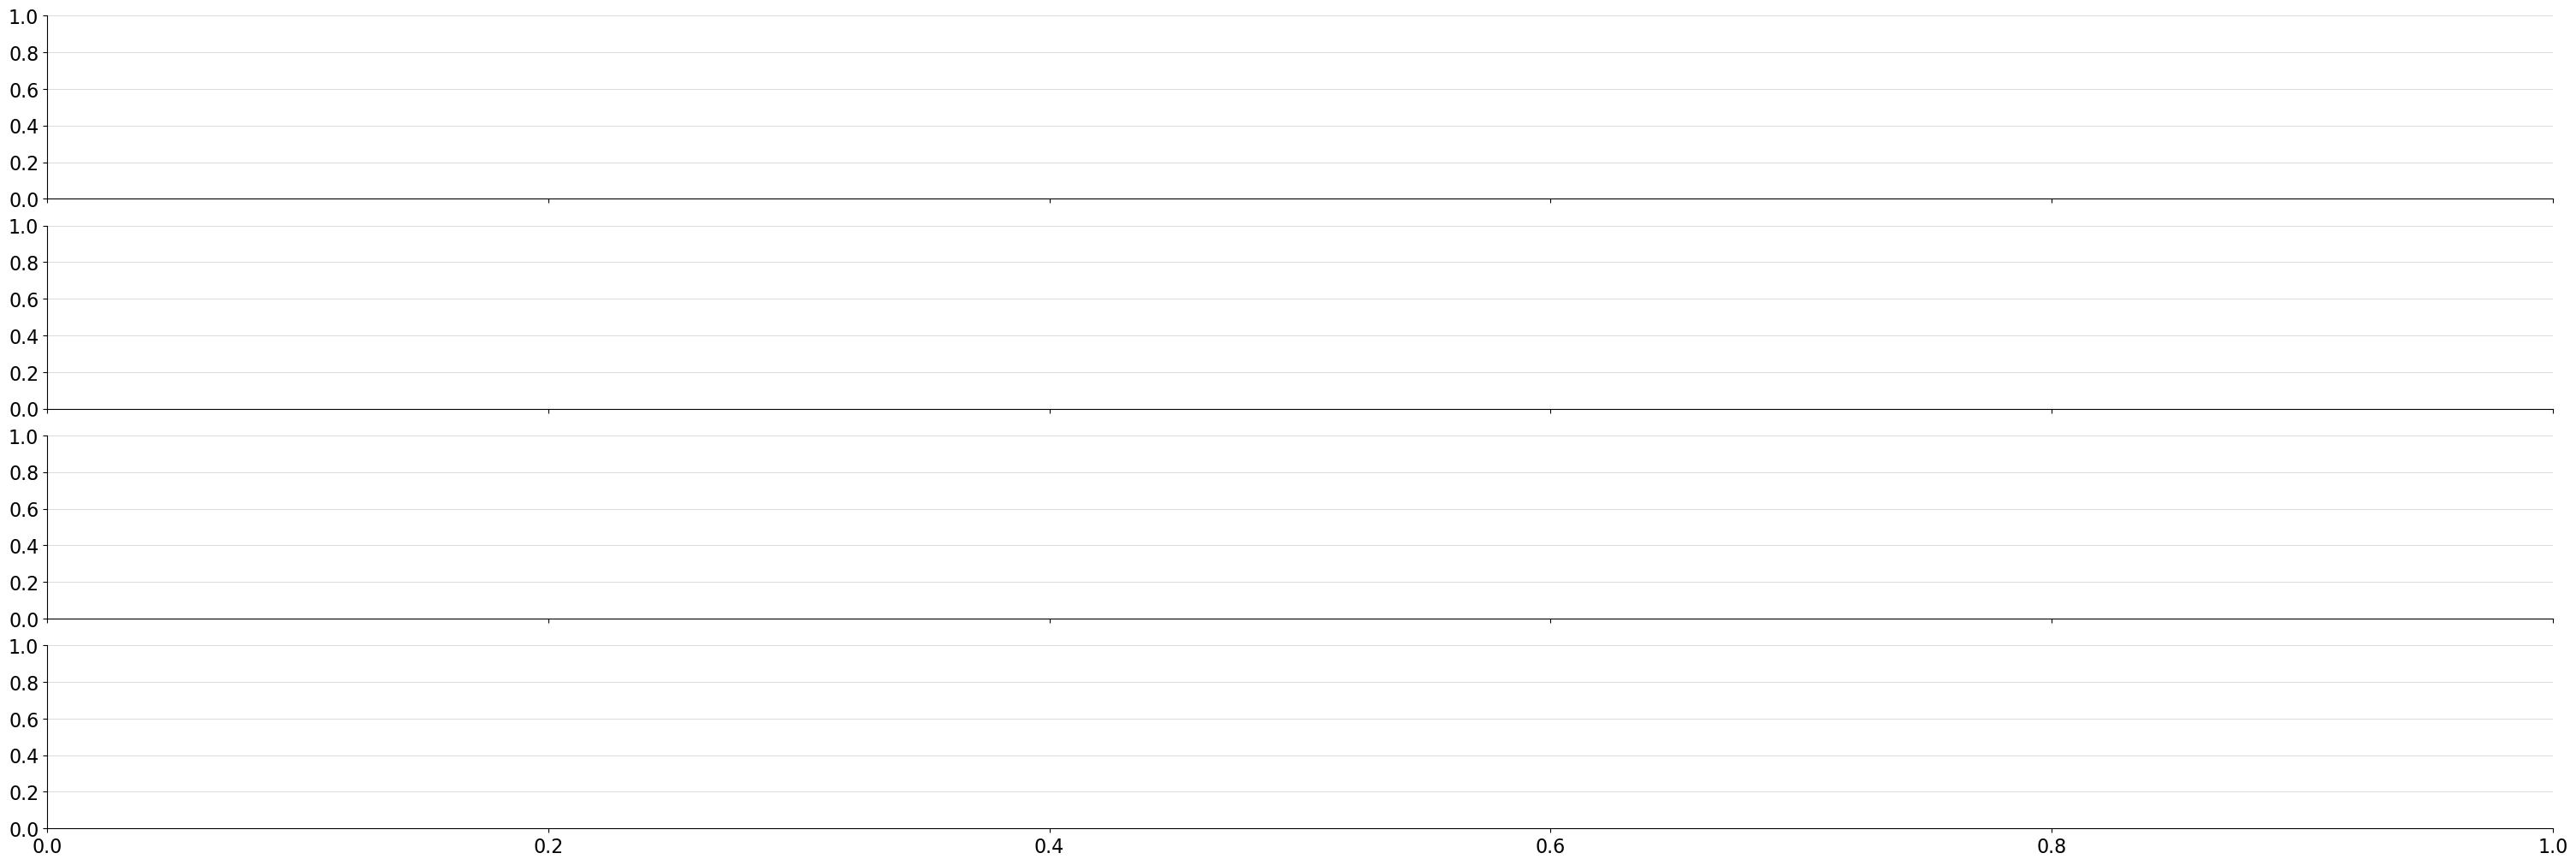

In [58]:
g.plot_simulation(x[0], x[1],
    plot_nodes = [
    [
    'Heat',
    'PIF7',
    'HSF',
    'HSP'
    ],


    [
    'CNGC2',
    'Ca2',
    'CMLCa2',
    'CDPK',
    ],
    ['CBP60G',
    'SARD1' ,
    'ICS',
    'SA',
    ]   ,

    [
    'RBOH',
    'ROS',
    'CAT',                            
    'SA',
    #                             
    ]

    ]

)

In [55]:
x[1]

array([[1.        , 1.        , 0.        , 1.        , 0.        ],
       [1.        , 1.        , 0.        , 1.        , 0.00172882],
       [1.        , 0.99999996, 0.        , 1.        , 0.01166179],
       ...,
       [1.        , 0.01549362, 0.        , 1.        , 0.99313782],
       [1.        , 0.01533946, 0.        , 1.        , 0.9932061 ],
       [1.        , 0.01521313, 0.        , 1.        , 0.99326205]])

In [156]:
print(bnet)


CNGC2, Heat
Ca2, CNGC2
PIF34, PIF34 & !DELLA
PIF7, ( Heat )
HSF, (PIF34 & PIF7) | Heat
HSP, HSF
CDPK, ( Ca2 )
CMLCa2, ( Ca2 )
RBOH, ( CDPK | Ca2 )
CAT, CMLCa2 & !SA
SA, ICS
ICS, CBP60G | SARD1
CBP60G, CMLCa2
SARD1, CMLCa2
ROS, RBOH & !CAT



In [ ]:
# SP5G, ( rx00597 ) & ( rx00657 )
SP5G, ( PIF34 | CO ) & ( !(CDF1) )
# SP6A, ( self ) & ( rx00660 & rx00658 ) &  ( rx00408 )
SP6A, ( !(SP5G) & !(TOC1) & !(SES) )
# SES, ( self ) & ( rx00661 )
SES, ( SES ) & ( !(CDF1) )
# CDF1, ( rx00655 | rx00656 ) & ( rx00654 & rx00405 )
CDF1, ( GI | TPL ) & ( !(FKF1) & !(StFLORE) )
# SWEET, ( self ) & ( rx00659 )
SWEET, ( SWEET ) & ( !(SP6A) )
# CO, ( self ) & ( rx00407 & rx00612 )
CO, 0
SOC1, 0
#( CO ) & ( !(CDF1) & !(SOC1) )


In [69]:
import re
import numpy as np




def clean_line(line):
    line = line.strip()
    if line == "targets, factors":
        return None

    m = re.match(r'^([^#]*)', line)
    if not m:
        return None

    return m.groups()[0].strip()


def parse_bnet(bnet):
    targets = set()

#     with open(bnet, 'r') as f, 
    with open("heat-sif.tsv", "w") as out:
        for line in bnet.split("\n"):
            line = clean_line(line)
            if line:
                target, factors = line.split(",")
                target = target.strip()
                if target in targets:
                    print(f"{target} already has an update function")
                    continue

                targets.update([target])

                final, edges = resolve_brackets(factors)
                edges += [f"{final}\t{target}"]

                out.write('\n'.join(edges))
                out.write('\n')


    with open("heat-sif-annot.tsv", "w") as out:
        out.write("name\ttype\tlabel\n")
        for and_i in ands:
            out.write(f"{and_i}\tlogical and\tand\n")
        for or_i in ors:
            out.write(f"{or_i}\tlogical or\tor\n")
        for not_i in nots:
            out.write(f"{not_i}\tlogical not\tnot\n")

def resolve(s):
    '''
    parse a string without brackets

    Returns
    -------

    r: str
        Replacement string

    edges: list of str
        Edges from string
    '''

    global and_i, or_i, not_i

    new_s = []
    edges = []

    # if len(factors) == 1:
    #     return s, []

    for factor in s.split("|"):
        nodes = [s.strip() for s in factor.split("&")]
        for i, node in enumerate(nodes):
            m =  re.match(r".*?!(.*)", node)
            if m:
                node = m.groups()[0].strip()

                not_node = f"not_{not_i}"
                not_i += 1

                edges += [f"{node}\t{not_node}"]

                nodes[i] = not_node
                nots.append(not_node)

        if len(nodes) > 1:

            and_node = f"and_{and_i}"
            and_i += 1

            edges += [f"{node}\t{and_node}" for node in nodes]
            new_s.append(and_node)

            ands.append(and_node)

        else:
            new_s.append(nodes[0])

    if len(new_s) > 1:
        or_node = f"or_{or_i}"
        or_i += 1
        edges += [f"{node}\t{or_node}" for node in new_s]
        ors.append(or_node)


        return or_node, edges


    else:
        return new_s[0], edges


def resolve_brackets(s):

    groups = []
    levels = []

    group_index = 1
    num_open_brackets = 0
    group = '0'
    previous_groups = []
    for i, c in enumerate(s):

        if c == '(':
            num_open_brackets += 1
            previous_groups.append(group)
            group = f"{group}.{group_index}"

        elif c == ')':
            num_open_brackets += -1
            group = previous_groups.pop()

            group_index +=1

        groups.append(group)
        levels.append(num_open_brackets)

    groups = np.array(groups)
    levels = np.array(levels)

    print(groups)

    max_level = max(levels)

    groups_to_parse = np.unique([groups[i] for i in np.where(levels==max_level)[0]])

    print(groups_to_parse)


    starts = []
    ends = []
    new_sub_s = []

    new_s = ''

    all_edges = []
    for g in groups_to_parse:
        indices = np.nonzero(groups==g)[0]

        print(indices)

        if s[indices[0]] == "(":
            sub_s = ''.join(s[i] for i in indices[1:]).strip()
        else:
            sub_s = ''.join(s[i] for i in indices[:]).strip()
        replace, edges = resolve(sub_s)

        print(f'replace "{sub_s}" with "{replace}"')

        starts.append(indices[0])
        ends.append(indices[-1])
        new_sub_s.append(replace)

        all_edges += edges

    # print(starts, ends, new_sub_s)

    # ends.append(len(s))

    starts = np.array(starts)
    ends = np.array(ends)

    idx = np.argsort(starts)
    starts = starts[idx]
    ends = ends[idx]
    
    base_start = 0
    new_s = ''
    for i, (start, end) in enumerate(zip(starts, ends)):
        new_s += s[base_start:start]
        new_s += new_sub_s[i]
        base_start = end+2
    new_s  += s[base_start:]
    new_s = new_s.strip()

    print(new_s)
    if re.findall(r"[&|()]", new_s):
        new_s, new_edges = resolve_brackets(new_s)
        all_edges += new_edges


    return new_s, all_edges


# s = "( ADK.cyt.p & DZR.cyt.m | tZRMP.cyt.m | APT.cyt.p & DZ.cyt.m ) & ! (tZ.cyt.m & AHK234.cyt.p | !(cZ.cyt.m & AHK234.cyt.p) | DZ.cyt.m & !AHK234.cyt.p | iP.cyt.m & AHK234.cyt.p )"
# print(s)
# new_s, edges = resolve_brackets(s)

# print("----\nfinal", new_s)

# print(edges)

# with open("test.tsv", "w") as out:
#     out.write('\n'.join(edges))
#     out.write('\n')


# with open("test-annot.tsv", "w") as out:
#     out.write("name\ttype\tlabel\n")
#     for and_i in ands:
#         out.write(f"{and_i}\tlogical and\t&\n")
#     for or_i in ors:
#         out.write(f"{or_i}\tlogical or\tor\n")
#     for not_i in nots:
#         out.write(f"{not_i}\tlogical not\tnot\n")

# print(ors, ands, nots)



global and_i, or_i, not_i
and_i = 0
or_i = 0
not_i = 0

ands = []
ors = []
nots = []

# import sys
# bnet = sys.argv[1]

#bnet = "/home/cbleker/research/NIB/ADAPT/skm-webapp/downloads_data/pss-boolnet-restricted.bnet"
# parse_bnet(bnet)

In [70]:
bnet

'\nCNGC2, Heat\nCa2, CNGC2\nPIF34, PIF34 & !DELLA\nPIF7, ( Heat )\nHSF, (PIF34 & PIF7) | Heat\nHSP, HSF\nCDPK, ( Ca2 )\nCMLCa2, ( Ca2 )\nRBOH, ( CDPK | Ca2 )\nCAT, CMLCa2 & !SA\nROS, RBOH & !CAT\n'

In [71]:
parse_bnet(bnet)

['0' '0' '0' '0' '0']
['0']
[0 1 2 3 4]
replace "Heat" with "Heat"
Heat
['0' '0' '0' '0' '0' '0']
['0']
[0 1 2 3 4 5]
replace "CNGC2" with "CNGC2"
CNGC2
['0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0']
['0']
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
replace "PIF34 & !DELLA" with "and_0"
and_0
['0' '0.1' '0.1' '0.1' '0.1' '0.1' '0.1' '0.1' '0']
['0.1']
[1 2 3 4 5 6 7]
replace "Heat" with "Heat"
Heat
['0' '0.1' '0.1' '0.1' '0.1' '0.1' '0.1' '0.1' '0.1' '0.1' '0.1' '0.1'
 '0.1' '0.1' '0' '0' '0' '0' '0' '0' '0' '0']
['0.1']
[ 1  2  3  4  5  6  7  8  9 10 11 12 13]
replace "PIF34 & PIF7" with "and_1"
and_1 | Heat
['0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0']
['0']
[ 0  1  2  3  4  5  6  7  8  9 10 11]
replace "and_1 | Heat" with "or_0"
or_0
['0' '0' '0' '0']
['0']
[0 1 2 3]
replace "HSF" with "HSF"
HSF
['0' '0.1' '0.1' '0.1' '0.1' '0.1' '0.1' '0']
['0.1']
[1 2 3 4 5 6]
replace "Ca2" with "Ca2"
Ca2
['0' '0.1' '0.1' '0.1' '0.1' '0.1' '0.1' '0']
['0.1']
[1 2 3 4 5 6]
rep